## 4. Positional Encoding

Transformers process all words in a sentence simultaneously, which means they have **no inherent sense of word order**. Without positional encoding, the sentences *"The dog bit the man"* and *"The man bit the dog"* would look identical to the model.

To fix this, we add a unique "position vector" to each word embedding. These vectors are calculated using sine and cosine functions of different frequencies, ensuring that each position has a unique and identifiable signature.

```mermaid
graph TD
    Word[Input Word] --> Emb[Embedding Vector]
    Pos[Position/Index] --> PE[Positional Encoding Vector]
    Emb --> Sum[Summing Vectors]
    PE --> Sum
    Sum --> Out[Input to Attention Layer]
```

## 1. Install and Import Libraries

We'll use PyTorch and the Transformers library from Hugging Face.

In [1]:
import torch
import torch.nn as nn
import math
import numpy as np
import matplotlib.pyplot as plt

# Check if transformers is available
try:
    from transformers import BertTokenizer, BertModel, BertForSequenceClassification
    print("Transformers library loaded successfully!")
except ImportError:
    print("Installing transformers...")
    import subprocess
    subprocess.check_call(['pip', 'install', 'transformers', '-q'])
    from transformers import BertTokenizer, BertModel, BertForSequenceClassification
    print("Transformers library installed and loaded!")

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

Installing transformers...
Transformers library installed and loaded!
PyTorch version: 2.10.0+cpu
CUDA available: False


## 2. Understanding Self-Attention

Self-attention allows the model to assign "importance" to different parts of the input relative to a specific word. For example, in the sentence *"The animal didn't cross the street because **it** was too tired"*, self-attention helps the model understand that **"it"** refers to **"animal"**, not "street".

### How it works (Q, K, V):
For every input token, the model creates three vectors:
1.  **Query (Q)**: "What am I looking for?"
2.  **Key (K)**: "How relevant am I to what is being looked for?"
3.  **Value (V)**: "What information do I actually hold?"

The score is calculated by taking the dot product of the Query with all Keys, applying a softmax function to get weights, and then summing the weighted Values.

```mermaid
graph LR
    Word[Input Word] --> Q[Query]
    Word --> K[Key]
    Word --> V[Value]
    Q --> Score[Dot Product Q*K / scale]
    K --> Score
    Score --> SM[Softmax weights]
    SM --> Sum[Weighted Sum of V]
    V --> Sum
    Sum --> Out[Attention Output]
```

In [2]:
# Simple Self-Attention Implementation

class SelfAttention(nn.Module):
    def __init__(self, embed_size, heads):
        super(SelfAttention, self).__init__()
        self.embed_size = embed_size
        self.heads = heads
        self.head_dim = embed_size // heads
        
        assert (
            self.head_dim * heads == embed_size
        ), "Embed size needs to be divisible by heads"
        
        # Linear projections for Q, K, V
        self.values = nn.Linear(self.head_dim, self.head_dim, bias=False)
        self.keys = nn.Linear(self.head_dim, self.head_dim, bias=False)
        self.queries = nn.Linear(self.head_dim, self.head_dim, bias=False)
        self.fc_out = nn.Linear(heads * self.head_dim, embed_size)
    
    def forward(self, values, keys, query, mask):
        N = query.shape[0]
        value_len, key_len, query_len = values.shape[1], keys.shape[1], query.shape[1]
        
        # Split embeddings into different heads
        values = values.reshape(N, value_len, self.heads, self.head_dim)
        keys = keys.reshape(N, key_len, self.heads, self.head_dim)
        queries = query.reshape(N, query_len, self.heads, self.head_dim)
        
        # Linear projections
        values = self.values(values)
        keys = self.keys(keys)
        queries = self.queries(queries)
        
        # Attention scores: (N, heads, query_len, key_len)
        energy = torch.einsum("nqhd,nkhd->nhqk", [queries, keys])
        
        if mask is not None:
            energy = energy.masked_fill(mask == 0, float("-1e20"))
        
        attention = torch.softmax(energy / (self.head_dim ** (1/2)), dim=3)
        
        # Apply attention to values
        out = torch.einsum("nhql,nlhd->nqhd", [attention, values]).reshape(
            N, query_len, self.heads * self.head_dim
        )
        
        return self.fc_out(out)

print("Self-Attention module defined!")

Self-Attention module defined!


## 3. Visualize Attention Weights

Let's create a simple example to understand how attention works.

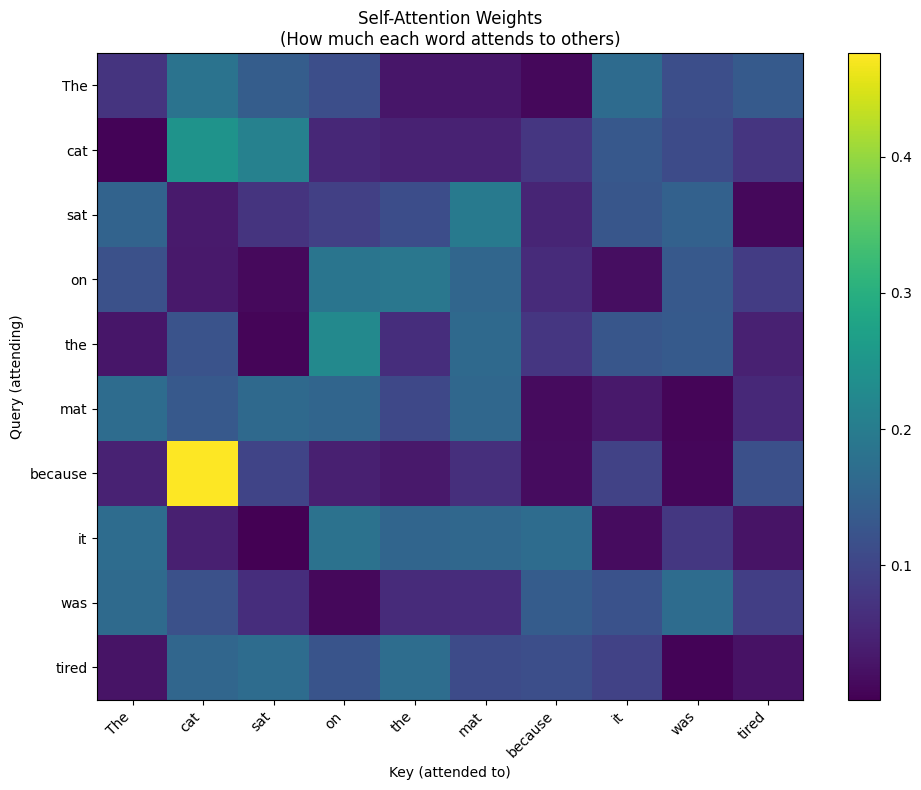


Notice how 'it' strongly attends to 'cat' (the antecedent)!


In [3]:
# Simple attention visualization

# Sample sentence
sentence = "The cat sat on the mat because it was tired"
words = sentence.split()
n_words = len(words)

# Simulate attention weights (in real transformers, these are learned)
# Here we'll create a pattern where "it" attends strongly to "cat"
np.random.seed(42)
attention_weights = np.random.rand(n_words, n_words)

# Make "it" (index 6) attend strongly to "cat" (index 1)
attention_weights[6, 1] = 0.8
attention_weights[6, :] = attention_weights[6, :] * 0.2
attention_weights[6, 1] = 0.8

# Normalize
attention_weights = attention_weights / attention_weights.sum(axis=1, keepdims=True)

# Plot attention heatmap
plt.figure(figsize=(10, 8))
plt.imshow(attention_weights, cmap='viridis', aspect='auto')
plt.xticks(range(n_words), words, rotation=45, ha='right')
plt.yticks(range(n_words), words)
plt.xlabel('Key (attended to)')
plt.ylabel('Query (attending)')
plt.title('Self-Attention Weights\n(How much each word attends to others)')
plt.colorbar()
plt.tight_layout()
plt.show()

print("\nNotice how 'it' strongly attends to 'cat' (the antecedent)!")

## 4. Positional Encoding

Transformers don't have a built-in sense of word order, so we add positional encodings to embeddings. We use sine and cosine functions of different frequencies.

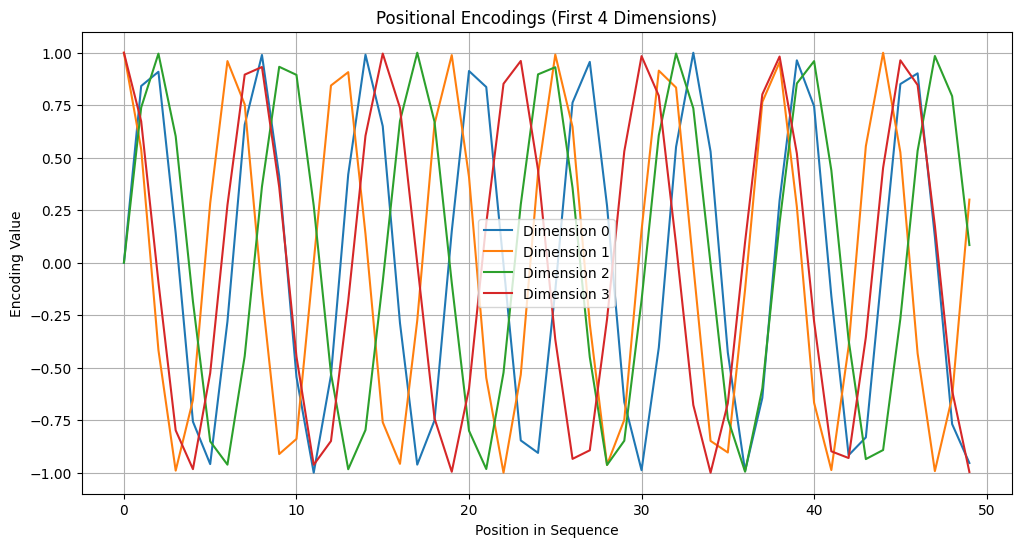


Each position gets a unique encoding pattern!


In [4]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super(PositionalEncoding, self).__init__()
        
        # Create positional encoding matrix
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)  # Add batch dimension
        
        self.register_buffer('pe', pe)
    
    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]

# Visualize positional encodings
d_model = 100  # Embedding dimension
max_len = 50   # Max sequence length

pos_encoder = PositionalEncoding(d_model, max_len)

# Get the encoding matrix
pe = pos_encoder.pe[0].numpy()

# Plot first few dimensions
plt.figure(figsize=(12, 6))
for i in range(4):
    plt.plot(pe[:, i], label=f'Dimension {i}')
plt.xlabel('Position in Sequence')
plt.ylabel('Encoding Value')
plt.title('Positional Encodings (First 4 Dimensions)')
plt.legend()
plt.grid(True)
plt.show()

print("\nEach position gets a unique encoding pattern!")

## 5. Using Real Transformers: BERT

**BERT** (Bidirectional Encoder Representations from Transformers) is one of the most famous transformer-based models. Unlike earlier models that read text left-to-right or right-to-left, BERT reads the entire sequence of words at once.

### Key Innovations of BERT:
1. **Pre-training**: BERT was pre-trained on a massive corpus (Wikipedia + BooksCorpus) using two tasks: **Masked Language Modeling (MLM)** and **Next Sentence Prediction (NSP)**.
2. **Transfer Learning**: You can take a pre-trained BERT model and "fine-tune" it on a specific task (like sentiment analysis) with very little data.

```mermaid
graph LR
    Text[Input Text] --> BERT[BERT Encoder]
    BERT --> Pool[Pooler Output / CLS Token]
    Pool --> Task[Downstream Task: e.g. Sentiment]
```

In [5]:
# Load pre-trained BERT model and tokenizer
print("Loading BERT model (this may take a moment)...")

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertModel.from_pretrained('bert-base-uncased')

print(f"BERT model loaded!")
print(f"Number of parameters: {sum(p.numel() for p in model.parameters()):,}")

Loading BERT model (this may take a moment)...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

d:\setups\ml-dl\.venv\Lib\site-packages\huggingface_hub\file_download.py:130: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Ahmad\.cache\huggingface\hub\models--bert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BERT model loaded!
Number of parameters: 109,482,240


## 6. Get BERT Embeddings

Now that we have the model, let's see how it represents text. When we pass a sentence through BERT, it returns a "Last Hidden State" - a high-dimensional vector for every single token in the input.

### Understanding the Output Shape:
- **Batch size (1)**: We processed one sentence.
- **Sequence length (12)**: The number of tokens (including special tokens [CLS] and [SEP]).
- **Hidden size (768)**: The size of the embedding vector for each token in BERT-base.

In [6]:
# Encode a sentence
sentence = "The cat sat on the mat because it was tired"

# Tokenize
inputs = tokenizer(sentence, return_tensors='pt', return_attention_mask=True)

print("Input tokens:")
print(tokenizer.convert_ids_to_tokens(inputs['input_ids'][0]))

# Get BERT outputs
with torch.no_grad():
    outputs = model(**inputs)

# Get the last hidden state (embeddings for each token)
last_hidden_state = outputs.last_hidden_state

print(f"\nLast hidden state shape: {last_hidden_state.shape}")
print(f"  - Batch size: {last_hidden_state.shape[0]}")
print(f"  - Sequence length: {last_hidden_state.shape[1]}")
print(f"  - Hidden size (embedding dim): {last_hidden_state.shape[2]}")

Input tokens:
['[CLS]', 'the', 'cat', 'sat', 'on', 'the', 'mat', 'because', 'it', 'was', 'tired', '[SEP]']

Last hidden state shape: torch.Size([1, 12, 768])
  - Batch size: 1
  - Sequence length: 12
  - Hidden size (embedding dim): 768


## 7. Contextual Word Embeddings

This is the "magic" of BERT. In older models like Word2Vec, the word "bank" always had the same vector. In BERT, the vector depends on the words around it.

Observe how the embedding for **"bank"** changes when it means a financial institution vs. a river bank. The "context" provided by the attention mechanism shifts the embedding in vector space.

In [7]:
# Compare embeddings for the word "bank" in different contexts

sentences = [
    "I went to the bank to deposit money",
    "The river bank was covered in grass"
]

embeddings = []

for sent in sentences:
    inputs = tokenizer(sent, return_tensors='pt', return_attention_mask=True)
    with torch.no_grad():
        outputs = model(**inputs)
    
    # Find the position of "bank" in the tokenized sentence
    tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])
    bank_idx = tokens.index('bank')
    
    # Get embedding for "bank"
    bank_embedding = outputs.last_hidden_state[0, bank_idx, :].numpy()
    embeddings.append(bank_embedding)
    
    print(f"Sentence: '{sent}'")
    print(f"Tokens: {tokens}")
    print(f"'bank' index: {bank_idx}")
    print()

# Calculate similarity between the two embeddings
cosine_sim = np.dot(embeddings[0], embeddings[1]) / (np.linalg.norm(embeddings[0]) * np.linalg.norm(embeddings[1]))
print(f"Cosine similarity between 'bank' embeddings: {cosine_sim:.4f}")
print("\n(Note: Similar but not identical - BERT captures context!)")

Sentence: 'I went to the bank to deposit money'
Tokens: ['[CLS]', 'i', 'went', 'to', 'the', 'bank', 'to', 'deposit', 'money', '[SEP]']
'bank' index: 5

Sentence: 'The river bank was covered in grass'
Tokens: ['[CLS]', 'the', 'river', 'bank', 'was', 'covered', 'in', 'grass', '[SEP]']
'bank' index: 3

Cosine similarity between 'bank' embeddings: 0.5038

(Note: Similar but not identical - BERT captures context!)


## 8. Sentiment Classification with BERT

To use BERT for classification, we typically add a small "head" (a linear layer) on top of the **[CLS] token**.

- **[CLS] Token**: The very first token in any BERT input. Its final hidden state is used as a summary of the entire sentence.
- **Fine-tuning**: We keep the BERT weights but train the new classification head on our specific labels (Positive/Negative).

```mermaid
graph LR
    I[Input Sentence] --> B[BERT Base]
    B --> C[CLS Token Vector]
    C --> H[Classification Head - Linear Layer]
    H --> O[Output: Positive/Negative]
```

In [8]:
# Load BERT for sequence classification
classifier = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=2  # Binary classification
)

# Sample texts
test_texts = [
    "I absolutely love this product! It's amazing!",
    "This is the worst experience I've ever had. Terrible!",
    "The movie was okay, nothing special."
]

# Predict
for text in test_texts:
    inputs = tokenizer(text, return_tensors='pt', truncation=True, max_length=128)
    with torch.no_grad():
        outputs = classifier(**inputs)
    
    predictions = torch.softmax(outputs.logits, dim=1)
    sentiment = "Positive" if predictions[0][1] > predictions[0][0] else "Negative"
    confidence = max(predictions[0]).item()
    
    print(f"Text: '{text[:50]}...'")
    print(f"  Sentiment: {sentiment} (Confidence: {confidence:.2%})")
    print()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Text: 'I absolutely love this product! It's amazing!...'
  Sentiment: Negative (Confidence: 51.25%)

Text: 'This is the worst experience I've ever had. Terrib...'
  Sentiment: Negative (Confidence: 51.68%)

Text: 'The movie was okay, nothing special....'
  Sentiment: Negative (Confidence: 56.12%)



## 9. Transformer Architecture Summary

```mermaid
graph TB
    A[Input Tokens] --> B[Token Embeddings]
    B --> C[Positional Encoding]
    C --> D[Multi-Head Self-Attention]
    D --> E[Add & Norm]
    E --> F[Feed-Forward Network]
    F --> G[Add & Norm]
    G --> H[Output Embeddings]
    
    D --> D1[Attention Head 1]
    D --> D2[Attention Head 2]
    D --> D3[Attention Head N]
```

### Key Takeaways:

1. **Self-Attention**: Allows each word to consider all other words
2. **Multi-Head**: Multiple attention heads capture different relationships
3. **Positional Encoding**: Adds order information to sequences
4. **Pre-training + Fine-tuning**: BERT is pre-trained on large corpus, then fine-tuned for specific tasks

### Popular Transformer Models:

| Model | Developer | Key Feature |
|-------|-----------|-------------|
| BERT | Google | Bidirectional, masked language model |
| GPT | OpenAI | Autoregressive, generative |
| T5 | Google | Text-to-text unified framework |
| RoBERTa | Facebook | Robustly optimized BERT |
| DistilBERT | HuggingFace | Lightweight, 60% faster |

## 10. Hands-on: Build a Simple Transformer

Let's put it all together with a minimal transformer block.

In [10]:
# Complete Transformer Block

class TransformerBlock(nn.Module):
    def __init__(self, embed_size, heads, dropout, forward_expansion):
        super(TransformerBlock, self).__init__()
        self.attention = SelfAttention(embed_size, heads)
        self.norm1 = nn.LayerNorm(embed_size)
        self.norm2 = nn.LayerNorm(embed_size)
        
        self.feed_forward = nn.Sequential(
            nn.Linear(embed_size, forward_expansion * embed_size),
            nn.ReLU(),
            nn.Linear(forward_expansion * embed_size, embed_size)
        )
        
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, value, key, query, mask):
        attention = self.attention(value, key, query, mask)
        
        # Add & Norm (residual connection)
        x = self.dropout(self.norm1(attention + query))
        
        # Feed Forward with Add & Norm
        forward = self.feed_forward(x)
        out = self.dropout(self.norm2(forward + x))
        
        return out

# Test the transformer block
embed_size = 256
heads = 8
dropout = 0.1
forward_expansion = 4

block = TransformerBlock(embed_size, heads, dropout, forward_expansion)

# Create dummy input
batch_size = 2
seq_length = 10
x = torch.randn(batch_size, seq_length, embed_size)

output = block(x, x, x, mask=None)

print(f"Input shape: {x.shape}")
print(f"Output shape: {output.shape}")
print("\n✅ Transformer block working correctly!")

Input shape: torch.Size([2, 10, 256])
Output shape: torch.Size([2, 10, 256])

✅ Transformer block working correctly!


## Summary

### What We Learned:
1. **Self-Attention Mechanism**: How words attend to each other
2. **Positional Encoding**: Adding order information
3. **BERT**: Pre-trained bidirectional transformer
4. **Contextual Embeddings**: Same word, different meaning in different contexts
5. **Fine-tuning**: Adapting pre-trained models for specific tasks

### Next Steps:
- Explore GPT models for text generation
- Learn about encoder-decoder architectures (T5, BART)
- Experiment with domain-specific transformers (BioBERT, SciBERT)
- Study attention visualization techniques